In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, Latex
from plot import graphic


EPS = 1e-5

def function(type, x): 
    match type:
        case 1:
            return np.pow(2, x - 0.1) - 1
        case 2:
            return np.pow(x - 0.2, 3)
        case 3:
            return np.pow(x,3)-5*np.pow(x,2)+2*x+1   # вариант 19
    
def bisection(a, b, eps, type_function):      # метод половинного деления
    x = np.array([])      # массив приближенных решений
    # x[-1] - последнее добавленное значение, т.е. текущее приближенное значение
    while(b - a >= 2*eps):
        x = np.append(x, (a + b)/2)
        if function(type_function, x[-1])*function(type_function, a) <= 0:
            b = x[-1]
        else:
            a = x[-1]
    return x

def nuton(x0, eps, type_function):            # метод Ньютона
    x = np.array([])                         # массив приближенных решений
    x = np.append(x, x0)                     # начальное приближение
    df = np.array([])                        # массив производных (это чтобы потом касательные построить на графике)
    while(x.size < 2 or np.abs(x[-1]-x[-2]) >= eps):     # продолжаем, пока размер массива меньше двух (это нужно, чтобы проверить разность текущего и прошлого приближенного значения) или не достигнем epsilon
        df = np.append(df, (function(type_function, x[-1])-function(type_function, x[-1]-EPS))/EPS)
        x = np.append(x, x[-1] - function(type_function, x[-1])/df[-1]) 
    return x, df

def secant(x0, x1, eps, type_function):           # метод секущих   
    x = np.array([])                            # массив приближенных решений
    x = np.append(x, x0)                        # начальное приближение 0
    x = np.append(x, x1)                        # начальное приближение 1
    while(x.size < 2 or np.abs(x[-1]-x[-2]) >= eps):     # продолжаем, пока размер массива меньше двух (это нужно, чтобы проверить разность текущего и прошлого приближенного значения) или не достигнем epsilon
        x = np.append(x, x[-1] - (x[-1]-x[-2])/(function(type_function, x[-1])-function(type_function, x[-2]))*(function(type_function, x[-1])))
    return x

def extremum(xmin, xmax, type_function):  # нахождение максимума
    x = np.arange(xmin, xmax, 1e-5)         # просто отсчеты по x
    y = function(type_function, x)          # отсчеты функции
    y1 = y - np.concatenate((np.array([y[0]]),np.roll(y, 1)[1:len(y)]))    # вычитаем функцию саму из себя, свдинутую на 1 отсчет, получим отрицательные и положительные области
    y2 = y1*np.roll(y1,1)           # так найдем перескок знака областей
    ind = np.where(y2 < 0)          # найдем индексы, на которых происходит перескок знака
    return x[ind]                   # иксы экстремумов


Метод половинного деления

<IPython.core.display.Latex object>

Приближенное решение: 0.0999908447265625
Абсолютная погрешность: 9.155273437505551e-06
Количество операций: 16
Время выполнения: 219.82192993164062 мкс
-----------------------


<IPython.core.display.Latex object>

Приближенное решение: 0.1999969482421875
Абсолютная погрешность: 3.0517578125111022e-06
Количество операций: 16
Время выполнения: 154.73365783691406 мкс
-----------------------


<IPython.core.display.Latex object>

Приближенное решение: -0.2851403794163332
Абсолютная погрешность: 3.794163331849454e-07
Количество операций: 19
Время выполнения: 308.75205993652344 мкс


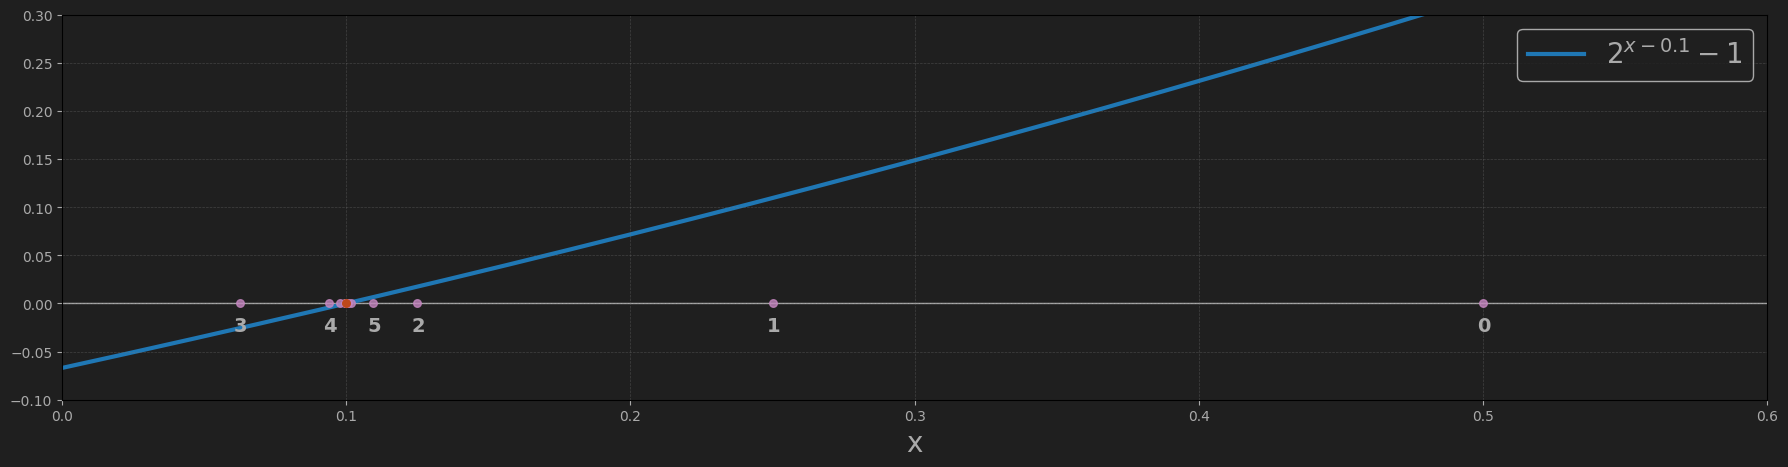

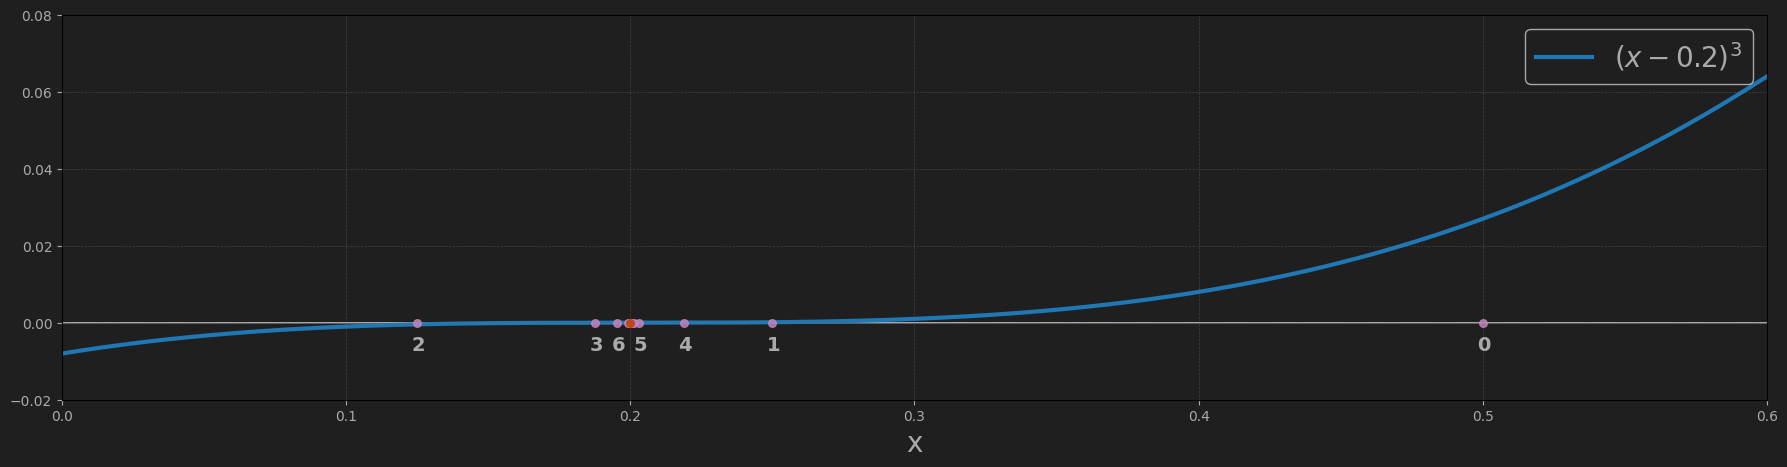

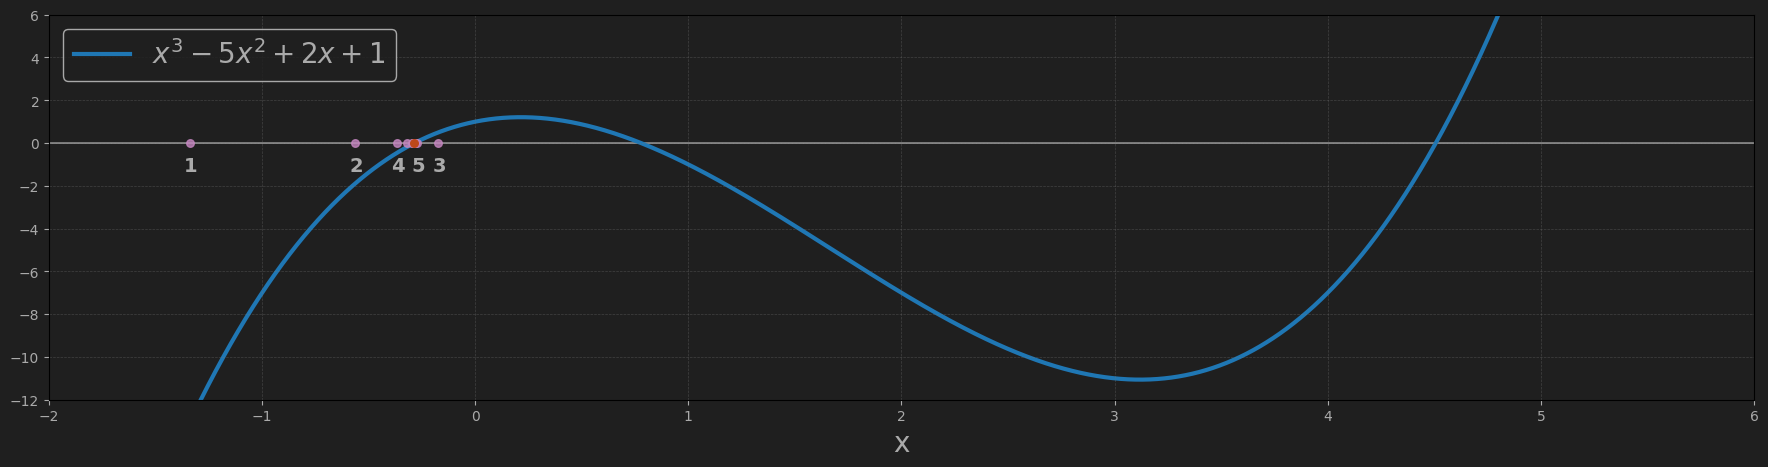

In [2]:
a = 0
b = 1
xmin = -6  # пусть отсчеты икса будут в этом диапазоне
xmax = 6
x_true1 = 0.1
x_true2 = 0.2
x_true3 = -0.28514
x_function = np.linspace(xmin, xmax, 100000, True)  # для построения функции
y_function1 = function(1, x_function)         # построение функии 2^(x - 0.1) - 1
y_function2 = function(2, x_function)         # построение функии (x - 0.2)^3
y_function3 = function(3, x_function)

### решение для 2^(x - 0.1) - 1
start_time1 = time.time()
x_points1 = bisection(a, b, EPS, 1)
end_time1 = time.time()
execute_time1 = end_time1-start_time1
y_points1 = np.zeros_like(x_points1)
n1 = len(x_points1)   # количество операций

### решение для (x - 0.2)^3
start_time2 = time.time()
x_points2 = bisection(a, b, EPS, 2)
end_time2 = time.time()
execute_time2 = end_time2-start_time2
y_points2 = np.zeros_like(x_points2)
n2 = len(x_points2)   # количество операций

### решение для x^3-5x^2+2x+1
x_extr = extremum(xmin, xmax, 3)
start_time3 = time.time()
x_points3 = bisection(xmin, x_extr[0], EPS, 3)  # берем промежуток с минимального икса до первого экстремума
end_time3 = time.time()
execute_time3 = end_time3-start_time3
y_points3 = np.zeros_like(x_points3)
n3 = len(x_points3)   # количество операций

### визуализация (по заданию не надо, это так для себя)
graphic(x_function, y_function1, x_points1, y_points1,[0, 0.6],[-0.1, 0.3], 6, r'$2^{x-0.1} - 1$', color='black', xaxis=True)
graphic(x_function, y_function2, x_points2, y_points2,[0, 0.6],[-0.02, 0.08], 7, r'$(x - 0.2)^3$', color='black', xaxis=True)
graphic(x_function, y_function3, x_points3, y_points3,[-2, 6],[-12, 6], 6, r'$x^3-5x^2+2x+1$', color='black', xaxis=True)


### вывод результатов
display(Latex(r'$2^{x-0.1} - 1$'))
print(f"Приближенное решение: {x_points1[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true1-x_points1[-1])}")
print(f"Количество операций: {n1}")
print(f"Время выполнения: {execute_time1*1e6} мкс")
print('-----------------------')
display(Latex(r'$(x - 0.2)^3$'))
print(f"Приближенное решение: {x_points2[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true2-x_points2[-1])}")
print(f"Количество операций: {n2}")
print(f"Время выполнения: {execute_time2*1e6} мкс")
print('-----------------------')
display(Latex(r'$x^3-5x^2+2x+1$'))
print(f"Приближенное решение: {x_points3[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true3-x_points3[-1])}")
print(f"Количество операций: {n3}")
print(f"Время выполнения: {execute_time3*1e6} мкс")

Метод Ньютона 

<IPython.core.display.Latex object>

Приближенное решение: 0.0999999999991068
Абсолютная погрешность: 8.932021788865541e-13
Количество операций: 5
Время выполнения: 162.1246337890625 мкс
-----------------------


<IPython.core.display.Latex object>

Приближенное решение: 0.20000031478593275
Абсолютная погрешность: 3.147859327368163e-07
Количество операций: 26
Время выполнения: 361.44256591796875 мкс
-----------------------


<IPython.core.display.Latex object>

Приближенное решение: -0.2851424818297887
Абсолютная погрешность: 2.481829788680834e-06
Количество операций: 8
Время выполнения: 261.7835998535156 мкс


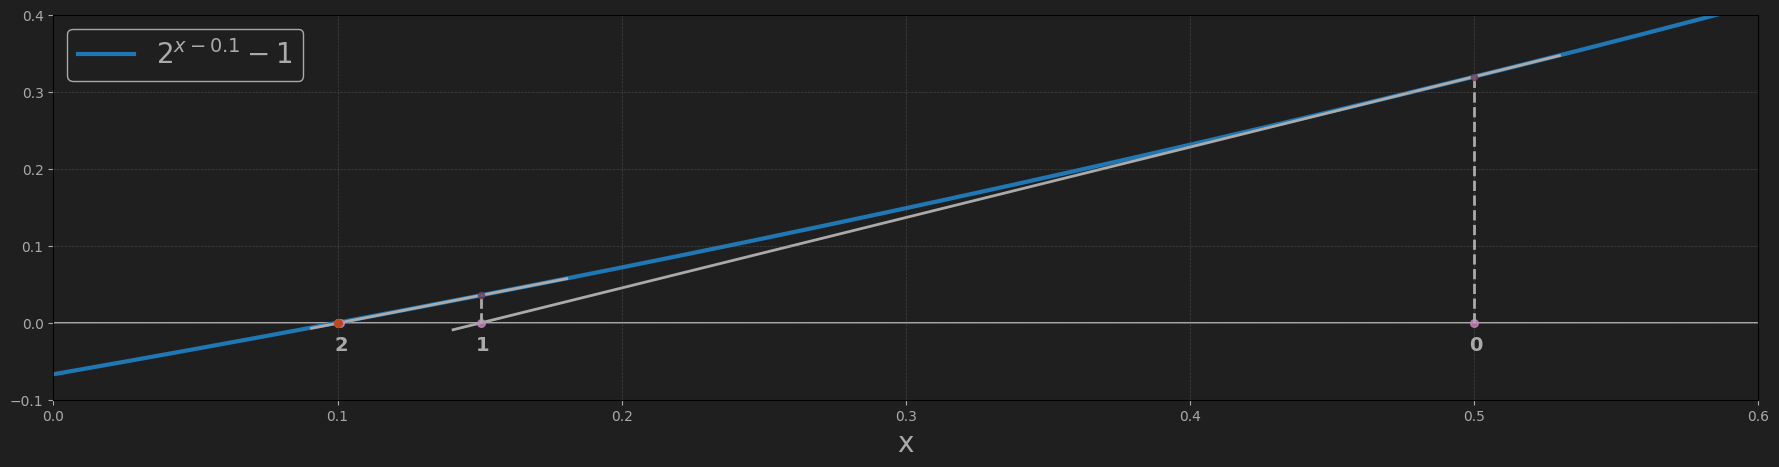

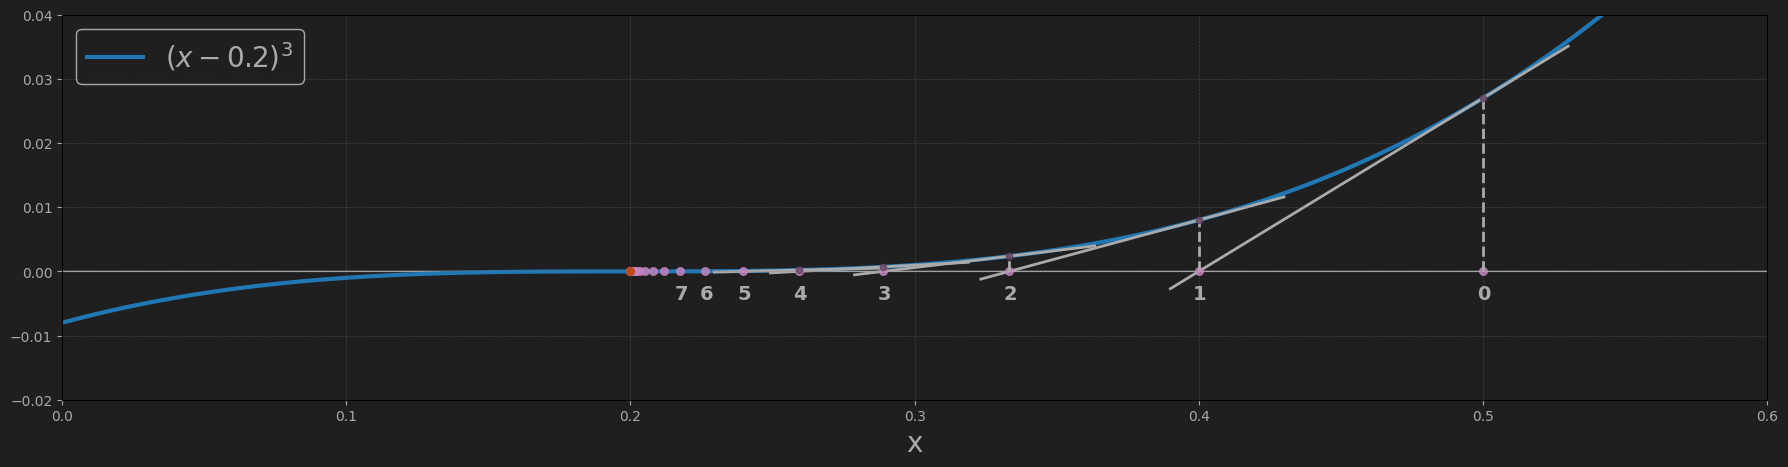

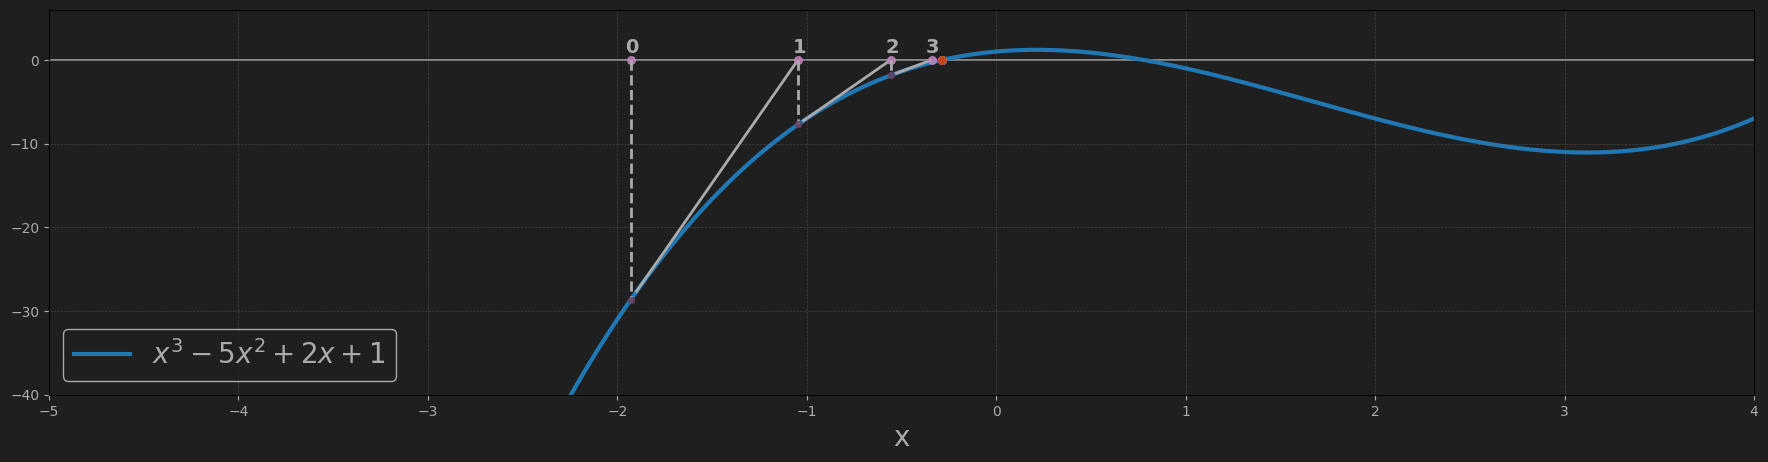

In [11]:
x_true1 = 0.1
x_true2 = 0.2
x_function = np.linspace(-10, 10, 100000, True)  # построение функции
y_function1 = function(1, x_function)         # построение функии 2^(x - 0.1) - 1  
y_function2 = function(2, x_function)         # построение функии (x - 0.2)^3 
y_function3 = function(3, x_function)

### решение для 2^(x - 0.1) - 1
start_time1 = time.time()
x_points1, df1 = nuton(0.5, EPS, 1)
end_time1 = time.time()
execute_time1 = end_time1-start_time1
y_points1 = np.zeros_like(x_points1)
n1 = len(x_points1)   # количество операций

### решение для (x - 0.2)^3
start_time2 = time.time()
x_points2, df2 = nuton(0.5, EPS, 2)
end_time2 = time.time()
execute_time2= end_time2-start_time2
y_points2 = np.zeros_like(x_points2)
n2 = len(x_points2)   # количество операций

### решение для x^3-5x^2+2x+1
x_extr = extremum(xmin, xmax, 3)
start_time3 = time.time()
x_points3, df3 = nuton((x_extr[0]+xmin)/3, EPS, 3) # 
end_time3 = time.time()
execute_time3 = end_time3-start_time3
y_points3 = np.zeros_like(x_points3)
n3 = len(x_points3)   # количество операций

### визуализация 
graphic(x_function, y_function1, x_points1, y_points1,[0, 0.6],[-0.1, 0.4], 3, r'$2^{x-0.1} - 1$', method='nuton', df=df1, function=function, type = 1, n_cas=2, color='black', xaxis=True)
graphic(x_function, y_function2, x_points2, y_points2,[0, 0.6],[-0.02, 0.04], 8, r'$(x - 0.2)^3$', method='nuton', df=df2, function=function, type = 2, n_cas=5, color='black', xaxis=True)
graphic(x_function, y_function3, x_points3, y_points3,[-5, 4],[-40, 6], 4, r'$x^3-5x^2+2x+1$', method='nuton', df=df3, function=function, type = 3, n_cas=3, color='black', xaxis=True, up=True)


### вывод результатов
display(Latex(r'$2^{x-0.1} - 1$'))
print(f"Приближенное решение: {x_points1[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true1-x_points1[-1])}")
print(f"Количество операций: {n1}")
print(f"Время выполнения: {execute_time1*1e6} мкс")
print('-----------------------')
display(Latex(r'$(x - 0.2)^3$'))
print(f"Приближенное решение: {x_points2[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true2-x_points2[-1])}")
print(f"Количество операций: {n2}")
print(f"Время выполнения: {execute_time2*1e6} мкс")
print('-----------------------')
display(Latex(r'$x^3-5x^2+2x+1$'))
print(f"Приближенное решение: {x_points3[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true3-x_points3[-1])}")
print(f"Количество операций: {n3}")
print(f"Время выполнения: {execute_time3*1e6} мкс")

Метод секущих

<IPython.core.display.Latex object>

Приближенное решение: 0.10000000000029145
Абсолютная погрешность: 2.914474217519114e-13
Количество операций: 7
Время выполнения: 175.23765563964844 мкс
-----------------------


<IPython.core.display.Latex object>

Приближенное решение: 0.2000268471475006
Абсолютная погрешность: 2.6847147500591584e-05
Количество операций: 33
Время выполнения: 363.8267517089844 мкс
-----------------------


<IPython.core.display.Latex object>

Приближенное решение: -0.28514248218145455
Абсолютная погрешность: 2.4821814545439302e-06
Количество операций: 10
Время выполнения: 248.6705780029297 мкс


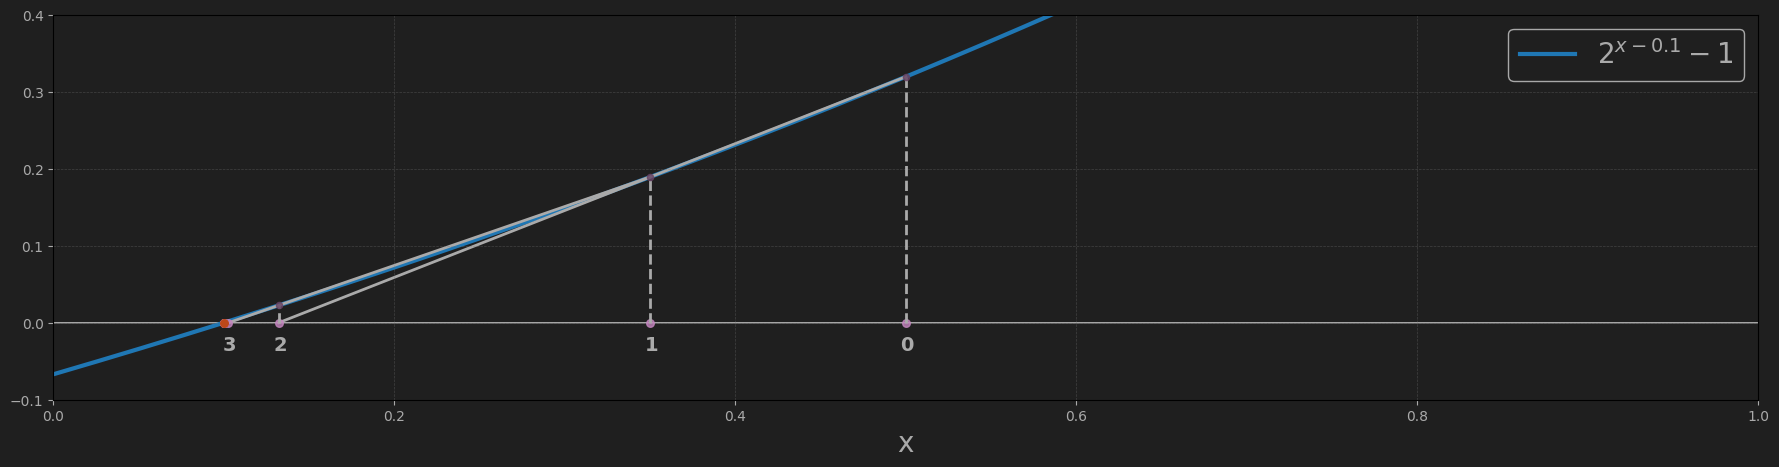

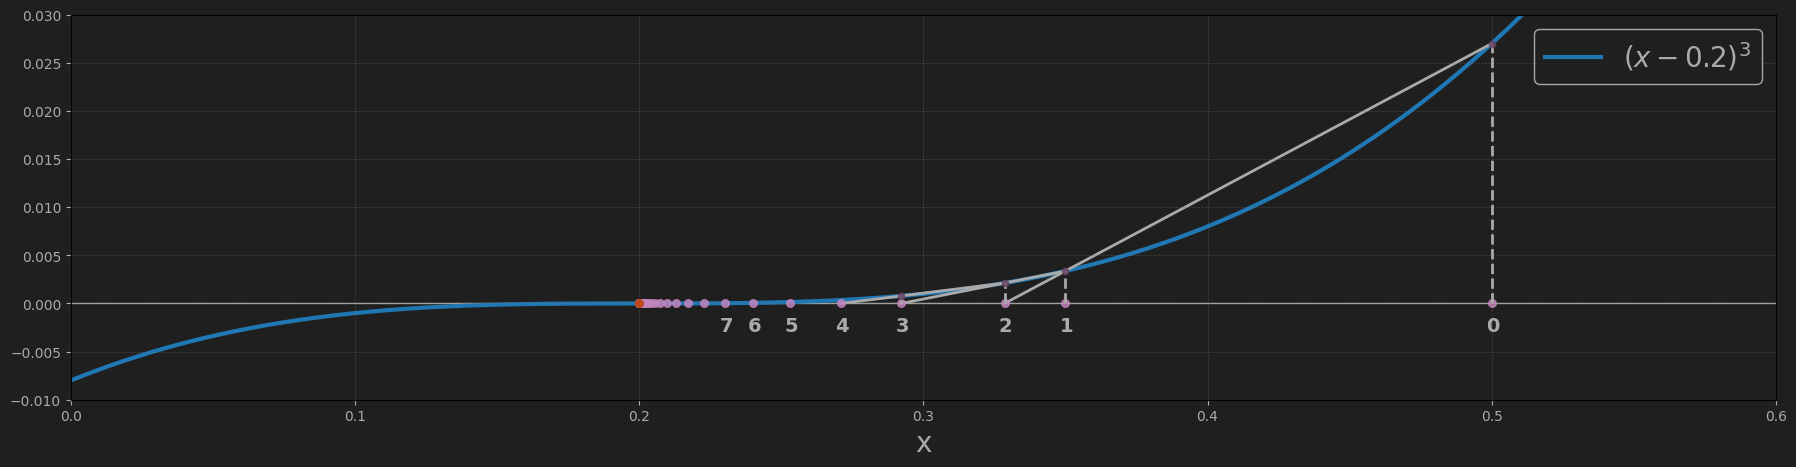

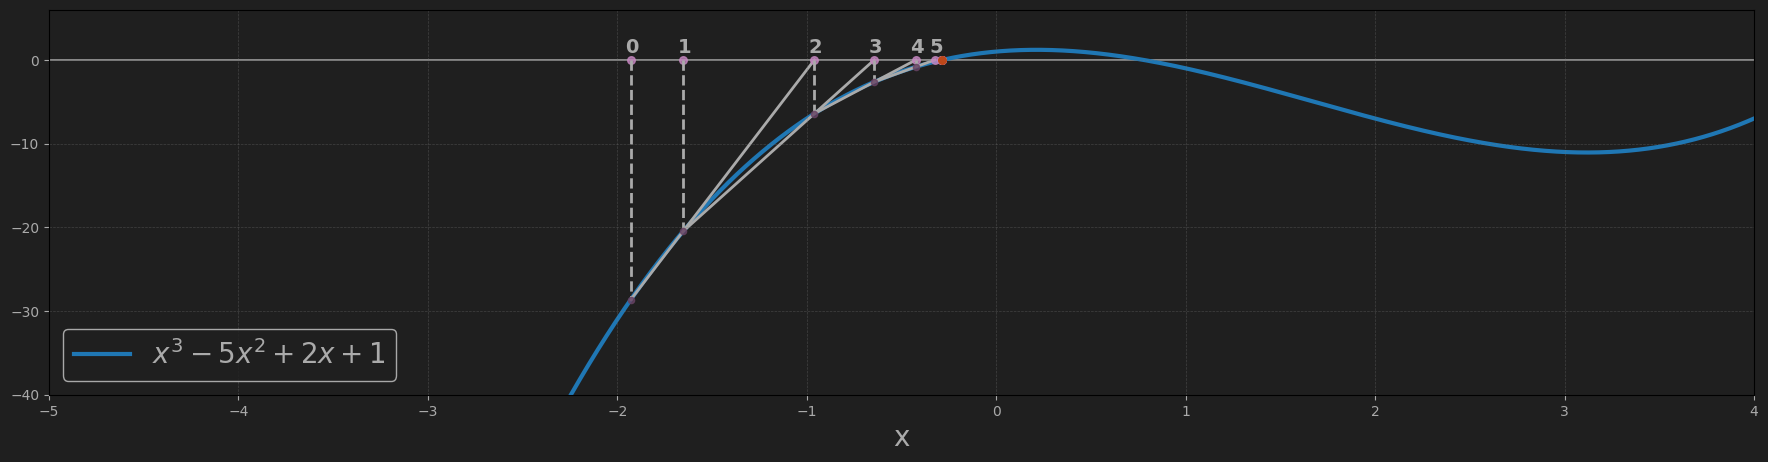

In [12]:
x_true1 = 0.1
x_true2 = 0.2
x_function = np.linspace(-10, 10, 100000, True)  # построение функции
y_function1 = function(1, x_function)         # построение функии 2^(x - 0.1) - 1  
y_function2 = function(2, x_function)         # построение функии (x - 0.2)^3 
y_function3 = function(3, x_function)

### решение для 2^(x - 0.1) - 1
start_time1 = time.time()
x_points1 = secant(0.5, 0.35, EPS, 1)
end_time1 = time.time()
execute_time1 = end_time1-start_time1
y_points1 = np.zeros_like(x_points1)
n1 = len(x_points1)   # количество операций

### решение для (x - 0.2)^3
start_time2 = time.time()
x_points2 = secant(0.5, 0.35, EPS, 2)
end_time2 = time.time()
execute_time2= end_time2-start_time2
y_points2 = np.zeros_like(x_points2)
n2 = len(x_points2)   # количество операций

### решение для x^3-5x^2+2x+1
x_extr = extremum(xmin, xmax, 3)
start_time3 = time.time()
x_points3 = secant((x_extr[0]+xmin)/3, (x_extr[0]+xmin)/3.5, EPS, 3) 
end_time3 = time.time()
execute_time3 = end_time3-start_time3
y_points3 = np.zeros_like(x_points3)
n3 = len(x_points3)   # количество операций


### визуализация 
graphic(x_function, y_function1, x_points1, y_points1,[0, 1],[-0.1, 0.4], 4, r'$2^{x-0.1} - 1$', method='secant', function=function, type = 1, n_cas=2, color='black', xaxis=True)
graphic(x_function, y_function2, x_points2, y_points2,[0, 0.6],[-0.01, 0.03], 8, r'$(x - 0.2)^3$', method='secant', function=function, type = 2, n_cas=3, color='black', xaxis=True)
graphic(x_function, y_function3, x_points3, y_points3,[-5, 4],[-40, 6], 6, r'$x^3-5x^2+2x+1$', method='secant', function=function, type = 3, n_cas=4, color='black', xaxis=True, up=True)

### вывод результатов
display(Latex(r'$2^{x-0.1} - 1$'))
print(f"Приближенное решение: {x_points1[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true1-x_points1[-1])}")
print(f"Количество операций: {n1}")
print(f"Время выполнения: {execute_time1*1e6} мкс")
print('-----------------------')
display(Latex(r'$(x - 0.2)^3$'))
print(f"Приближенное решение: {x_points2[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true2-x_points2[-1])}")
print(f"Количество операций: {n2}")
print(f"Время выполнения: {execute_time2*1e6} мкс")
print('-----------------------')
display(Latex(r'$x^3-5x^2+2x+1$'))
print(f"Приближенное решение: {x_points3[-1]}")
print(f"Абсолютная погрешность: {np.abs(x_true3-x_points3[-1])}")
print(f"Количество операций: {n3}")
print(f"Время выполнения: {execute_time3*1e6} мкс")